<a href="https://colab.research.google.com/github/phzfi/ai-course/blob/main/rl/number_guessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# parameters

RANGE = 1000
MAX_TRIES = 50

In [ ]:
import numpy as np

class NumberGuessingGame:
    def __init__(self, low=1, high=1000):
        self.low = low
        self.high = high
        self.target = np.random.randint(self.low, self.high + 1)
        self.count = 0
        self.done = False

    def reset(self):
        self.target = np.random.randint(self.low, self.high + 1)
        self.done = False
        return self.target

    def step(self, guess):
        if self.done:
            raise ValueError("Game has finished, please reset the game.")

        self.count += 1
        if guess == self.target:
            reward = 100  # High reward for correct guess
            self.done = True
        else:
            # Provide reward based on the proximity of the guess to the target
            reward = - self.count
            self.done = False

        return reward, np.sign(self.target - guess)


In [ ]:
import unittest

class TestNumberGuessingGame(unittest.TestCase):
    GAME_TARGET = 100

    def setUp(self):
        self.game = NumberGuessingGame()
        self.game.target = self.GAME_TARGET

    def test_game_initialization(self):
        self.assertTrue(self.game.low <= self.game.target <= self.game.high)

    def test_reward_is_smaller_after_more_tries(self):
        reward, _ = self.game.step(2)
        self.assertEqual(-1, reward)
        reward, _ = self.game.step(2)
        self.assertEqual(-2, reward)

    def test_return_negative_if_guess_is_bigger(self):
        _, result = self.game.step(101)
        self.assertEqual(-1, result)

    def test_return_positive_if_guess_is_smaller(self):
        _, result = self.game.step(99)
        self.assertEqual(1, result)

    def test_return_zero_if_guess_is_correct(self):
        _, result = self.game.step(100)
        self.assertEqual(0, result)

res = unittest.main(argv=[''], verbosity=3, exit=False)

assert len(res.result.failures) == 0, "Test failed"
print("All tests passed!")

test_game_initialization (__main__.TestNumberGuessingGame) ... ok
test_return_negative_if_guess_is_bigger (__main__.TestNumberGuessingGame) ... ok
test_return_positive_if_guess_is_smaller (__main__.TestNumberGuessingGame) ... ok
test_return_zero_if_guess_is_correct (__main__.TestNumberGuessingGame) ... ok
test_reward_is_smaller_after_more_tries (__main__.TestNumberGuessingGame) ... ok

----------------------------------------------------------------------
Ran 5 tests in 0.050s

OK


All tests passed!


Plot the game

In [ ]:
def plot_game(target, steps):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.xlabel('Step')
    plt.ylabel('Guess')
    plt.hlines(target, 0, len(steps) - 1, colors='g', linestyles='dashed')
    plt.xticks(range(len(steps)))
    plt.yticks(range(0, 1001, 100))
    plt.title('Number Guessing Game')
    plt.plot(steps, label='Number of steps')


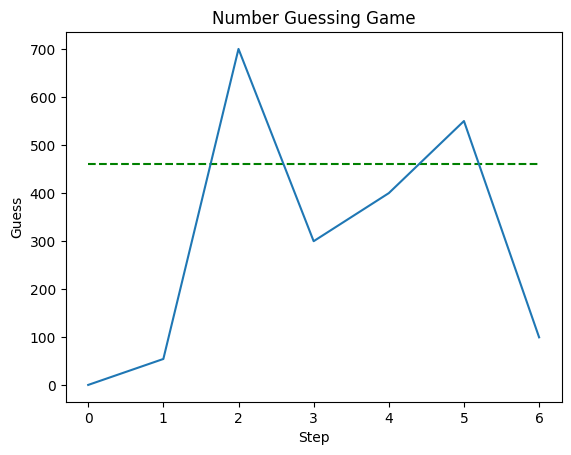

In [ ]:
plot_game(target=460, steps=[1, 55, 700, 300, 400, 550, 100])

Experience replay buffer

From model we want in each step the following input and output:

Input:

 * guess value
 * the reward (negative for misses, 100 for hit)
 * result (-1 or +1 or 0)

Output:

 * next guess (to be given to environment for estimation)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, Input, Lambda
from tensorflow.keras.optimizers import Adam

def create_rnn_agent():
    model = Sequential([
        Input((None, 3)),
        LSTM(MAX_TRIES, return_sequences=False),
        Dense(1, activation='sigmoid'),
        Lambda(lambda x: x * (MAX_TRIES - 1) + 1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['accuracy'])
    return model


Single pass through game and learning.

In [ ]:
from collections import namedtuple

GameStep = namedtuple('GameStep', ['guess', 'reward', 'result'])

exploration_rate = 0.2

def play_game_and_teach_agent(guessing_game, agent):
    high = guessing_game.high
    low = guessing_game.low
    target = guessing_game.reset()
    first_guess = np.random.randint(low, high + 1)
    first_reward, first_result = guessing_game.step(first_guess)
    game_step = GameStep(guess=first_guess, reward=first_reward, result=first_result)
    done = False
    transitions = [game_step]
    while not done:
        guess = 0
        if np.random.rand() < exploration_rate:
            guess = np.random.randint(low, high + 1)
        else:
            input = np.array(transitions).reshape(1, -1, 3)
            prediction = agent.predict_on_batch(input)
            guess = np.argmax(prediction, axis=1)[0]

        print(guess)
        reward, result = guessing_game.step(guess)
        game_step = GameStep(guess=guess, reward=reward, result=result)
        transitions.append(game_step)
        done = result == 0 or len(transitions) >= MAX_TRIES

    x = np.array(transitions).reshape(1, -1, 3)
    y = np.array([guess])

    def train_model_on_episode():
        # use policy gradient method, for example
        agent.train_on_batch(x, y)


    train_model_on_episode()


guessing_game = NumberGuessingGame(high=RANGE)
agent = create_rnn_agent()

play_game_and_teach_agent(guessing_game, agent)

0
0
0
0
0
0
0
0
0
0
0
31
11
0
0
0
0
0
0
886
0
0
0
0
0
334
0
101
0
0
0
0
0
0
0
0
0
0
0
0
762
430
0
0
0
0
0
0
0


This does not look promising! The hope was that the agent eventually finds some sort of binary search. But the agent is most probably not able to guess the number at all, because there is too big set of actions and it would require huge number of timesteps.

To make this example interesting, perhaps we should lower the limit the objective and guess only the numbers from 1 to 10, for example.

The other idea is to limit the action set, so that agent can for example only propose numbers N+1 or N-1, where N is the previously proposed number.